### **Practical Assignment - Machine Learning I**
##### Work done by:

Enrico Sanchez, upXXXXXXXXX

Enzo Grigorio, up202404041

Matheus Guerra, upXXXXXXXXX

Implementation based on the repository [Rushter/MLAlgorithms](https://github.com/rushter/MLAlgorithms/), as permitted by the assignement instructions.

### Hypothesis (Phase 1)
The **k-NN algorithm** is an instance-based learning method that determines a point's class based on the simple majority of its nearest neighbors. Our hypothesis is that it exhibits low robustness to **Dataset Group 1 (Noise/Outliers)** due to the following factors:

* **Local Sensitivity**: With a low $k$ value, a single incorrectly positioned outlier can "capture" the neighborhood of legitimate points, forcing a misclassification.
* **Distance Metric Issues**: Since the standard (unweighted) k-NN treats all neighbors equally, an outlier has the same influence on the decision as a point that is much closer and more representative of the class.
* **Decision Boundary Distortion**: The presence of noise creates "islands" of incorrect classes in the feature space, fragmenting the decision boundary and hindering the model's ability to generalize.

This evaluation is part of **Phase 1**, where we aim to understand how these data characteristics affect the standard version of the algorithm before proposing a more robust variant in **Phase 2**.

#### ***Imports***

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

from knn.knn import KNNClassifier

### ***Loading the datasets***

In [34]:
folder_name = 'noise_outliers'

selected_datasets = [
    'dataset_13_breast-cancer.csv',
    'dataset_27_colic.csv',
    'dataset_31_credit-g.csv',
    'dataset_38_sick.csv',
    'dataset_50_tic-tac-toe.csv',
    'dataset_56_vote.csv',
    'dataset_451_irish.csv',
    'dataset_466_schizo.csv',
    'dataset_745_auto_price.csv',
    'dataset_786_cleveland.csv',
]

data_registry = {}

for ds_name in selected_datasets:
    path = os.path.join(folder_name, ds_name)
    df_raw = pd.read_csv(path)
        
    print(f"\n" + "="*50)
    print(f"DATASET: {ds_name}")
    print("="*50)
    print("\n[ORIGINAL STATE]")
    display(df_raw.head())

    df = df_raw.copy()
        
    for col in df.columns:
        mode_val = df[col].mode()
        if not mode_val.empty:
            df[col] = df[col].fillna(mode_val[0])
        else:
            df[col] = df[col].fillna(0)
    
    cols_to_fix = [col for col in df.columns if not pd.api.types.is_numeric_dtype(df[col])]
    
    for col in cols_to_fix:
        df[col] = df[col].astype('category').cat.codes
        
    print("\n[ENCODED STATE]")
    display(df.head())
    
    print(f"\n[TRANSFORMATION SUMMARY]")
    print(f"• Alterou: 'Categorical/Object' para 'Integer (Categorical Codes)'")
    print(f"• Colunas afetadas: {cols_to_fix}")
    print(f"• Regra Z: Imputação de nulos pela Moda + Label Encoding via Categorical Codes.")
    print(f"• Normalização: Aplicada Min-Max Scaling [0, 1] para interpretação correta do k-NN.")
    
    X = df.iloc[:, :-1].values
    y = df.iloc[:, -1].values
    X_min = X.min(axis=0)
    X_max = X.max(axis=0)
    X_normalized = (X - X_min) / (X_max - X_min + 1e-10)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_normalized, y, test_size=0.3, random_state=42
    )
    data_registry[ds_name] = (X_train, X_test, y_train, y_test)


DATASET: dataset_13_breast-cancer.csv

[ORIGINAL STATE]


,age,menopause,tumor-size,inv-nodes,node-caps,deg-malig,breast,breast-quad,irradiat,Class
0,40-49,premeno,15-19,0-2,yes,3,right,left_up,no,recurrence-events
1,50-59,ge40,15-19,0-2,no,1,right,central,no,no-recurrence-events
2,50-59,ge40,35-39,0-2,no,2,left,left_low,no,recurrence-events
3,40-49,premeno,35-39,0-2,yes,3,right,left_low,yes,no-recurrence-events
4,40-49,premeno,30-34,3-5,yes,2,left,right_up,no,recurrence-events



[ENCODED STATE]


,age,menopause,tumor-size,inv-nodes,node-caps,deg-malig,breast,breast-quad,irradiat,Class
0,2,2,2,0,1,3,1,2,0,1
1,3,0,2,0,0,1,1,0,0,0
2,3,0,6,0,0,2,0,1,0,1
3,2,2,6,0,1,3,1,1,1,0
4,2,2,5,4,1,2,0,4,0,1



[TRANSFORMATION SUMMARY]
• Alterou: 'Categorical/Object' para 'Integer (Categorical Codes)'
• Colunas afetadas: ['age', 'menopause', 'tumor-size', 'inv-nodes', 'node-caps', 'breast', 'breast-quad', 'irradiat', 'Class']
• Regra Z: Imputação de nulos pela Moda + Label Encoding via Categorical Codes.
• Normalização: Aplicada Min-Max Scaling [0, 1] para interpretação correta do k-NN.

DATASET: dataset_27_colic.csv

[ORIGINAL STATE]


...


[TRANSFORMATION SUMMARY]
• Alterou: 'Categorical/Object' para 'Integer (Categorical Codes)'
• Colunas afetadas: ['binaryClass']
• Regra Z: Imputação de nulos pela Moda + Label Encoding via Categorical Codes.
• Normalização: Aplicada Min-Max Scaling [0, 1] para interpretação correta do k-NN.

DATASET: dataset_786_cleveland.csv

[ORIGINAL STATE]


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,binaryClass
0,63,1,1,145,233.0,1,2,150,0,2.3,3,0.0,6.0,P
1,67,1,4,160,286.0,0,2,108,1,1.5,2,3.0,3.0,N
2,67,1,4,120,229.0,0,2,129,1,2.6,2,2.0,7.0,N
3,37,1,3,130,250.0,0,0,187,0,3.5,3,0.0,3.0,P
4,41,0,2,130,204.0,0,2,172,0,1.4,1,0.0,3.0,P



[ENCODED STATE]


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,binaryClass
0,63,1,1,145,233.0,1,2,150,0,2.3,3,0.0,6.0,1
1,67,1,4,160,286.0,0,2,108,1,1.5,2,3.0,3.0,0
2,67,1,4,120,229.0,0,2,129,1,2.6,2,2.0,7.0,0
3,37,1,3,130,250.0,0,0,187,0,3.5,3,0.0,3.0,1
4,41,0,2,130,204.0,0,2,172,0,1.4,1,0.0,3.0,1



[TRANSFORMATION SUMMARY]
• Alterou: 'Categorical/Object' para 'Integer (Categorical Codes)'
• Colunas afetadas: ['binaryClass']
• Regra Z: Imputação de nulos pela Moda + Label Encoding via Categorical Codes.
• Normalização: Aplicada Min-Max Scaling [0, 1] para interpretação correta do k-NN.


### ***Visualizing the datasets***
PCA reduction for easier visualization of the datasets in a two dimension space.

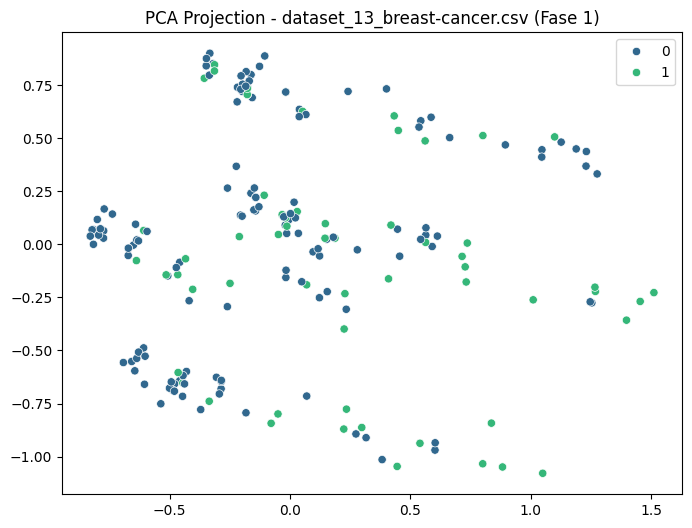

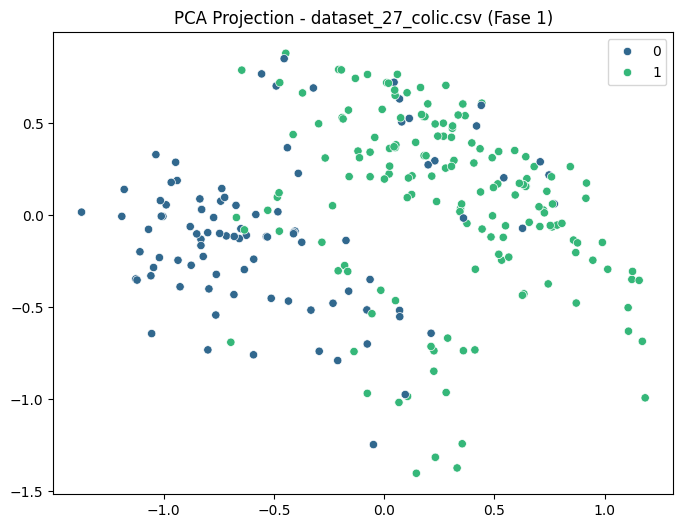

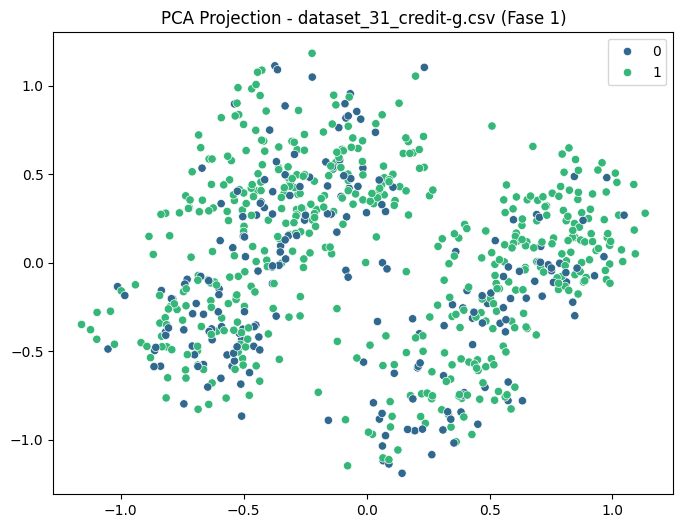

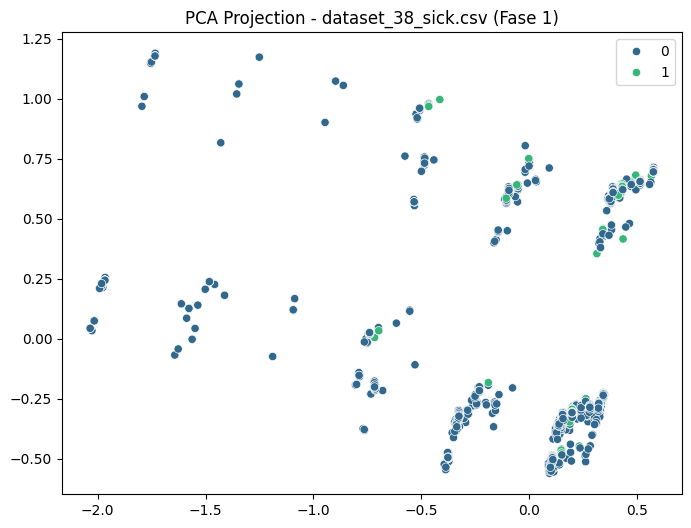

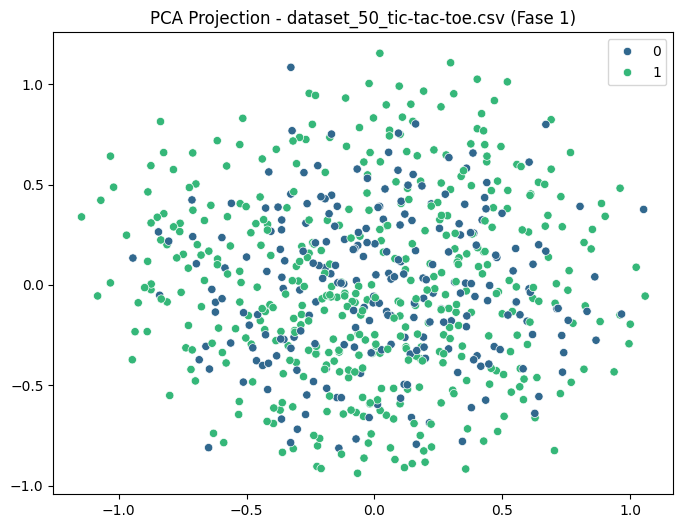

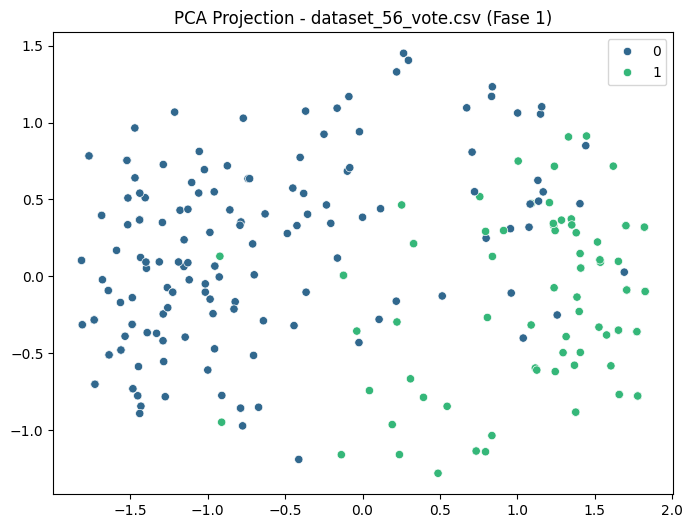

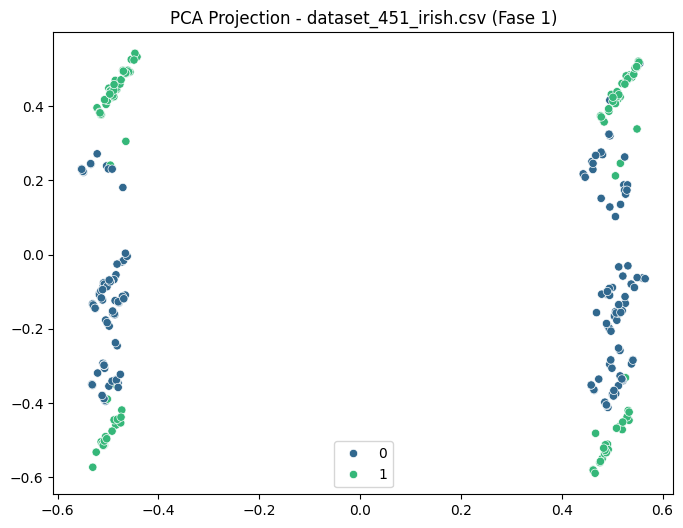

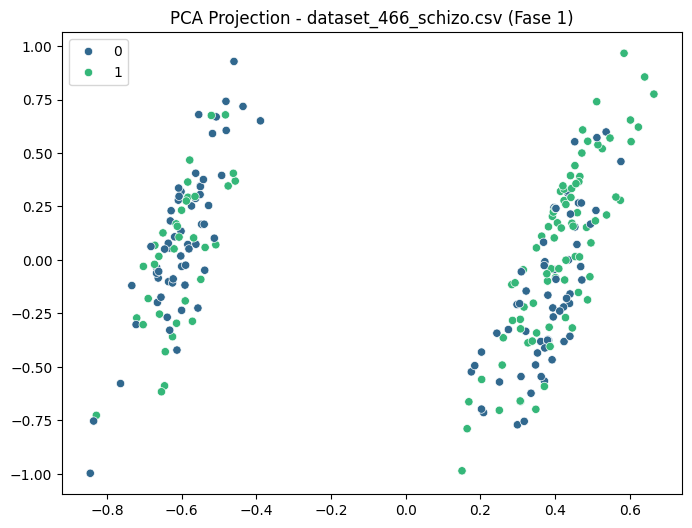

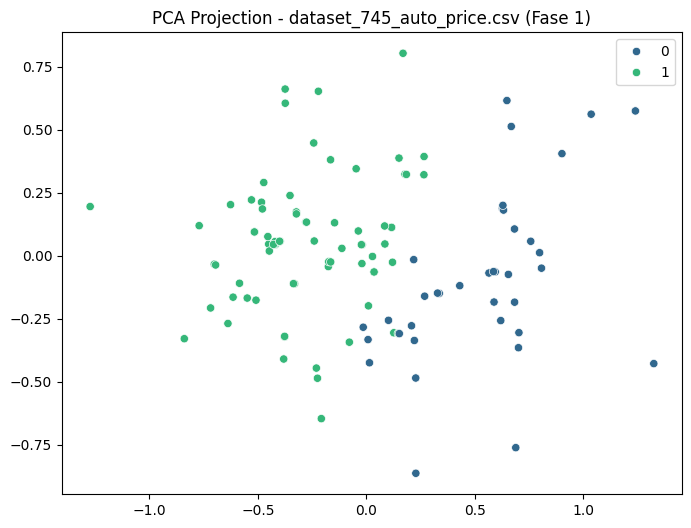

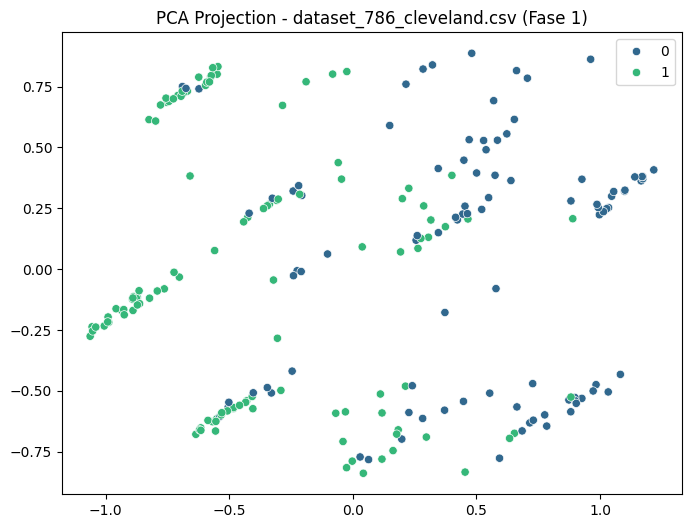

In [26]:
for ds_name in selected_datasets:
    X_train, X_test, y_train, y_test = data_registry[ds_name]
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_train)

    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_train, palette='viridis')
    plt.title(f"PCA Projection - {ds_name} (Fase 1)")
    plt.show()

### ***Benchmark***

In [31]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
results_phase1 = []

for ds_name in selected_datasets:
    path = os.path.join(folder_name, ds_name)
    df = pd.read_csv(path)
    
    for col in df.columns:
        mode_val = df[col].mode()
        if not mode_val.empty:
            df[col] = df[col].fillna(mode_val[0])
        else:
            df[col] = df[col].fillna(0)

    for col in df.columns:
        if not pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].astype('category').cat.codes

    X = df.iloc[:, :-1].values
    y = df.iloc[:, -1].values
    
    X_min = X.min(axis=0)
    X_max = X.max(axis=0)
    X = (X - X_min) / (X_max - X_min + 1e-10)
    
    fold_accuracies = []
    
    for train_idx, test_idx in cv.split(X, y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        model = KNNClassifier(k=3)        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        acc = np.mean(y_pred == y_test)
        fold_accuracies.append(acc)
    
    results_phase1.append({
        "Dataset": ds_name, 
        "Mean Accuracy": np.mean(fold_accuracies),
        "Standard Error": np.std(fold_accuracies) / np.sqrt(10)
    })

df_benchmark = pd.DataFrame(results_phase1)
df_benchmark.to_csv('knn_phase1_benchmark_results.csv', index=False)
display(df_benchmark)

,Dataset,Mean Accuracy,Standard Error
0,dataset_13_breast-cancer.csv,0.709236,0.016563
1,dataset_27_colic.csv,0.825826,0.013244
2,dataset_31_credit-g.csv,0.695000,0.011158
3,dataset_38_sick.csv,0.961296,0.002601
4,dataset_50_tic-tac-toe.csv,0.778739,0.011718
5,dataset_56_vote.csv,0.921934,0.018224
6,dataset_451_irish.csv,0.956000,0.006812
7,dataset_466_schizo.csv,0.661765,0.019174
8,dataset_745_auto_price.csv,0.950000,0.021287
9,dataset_786_cleveland.csv,0.798495,0.019192
